# 02 — Exploration du corpus principal Hugging Face

## Objectif
Explorer le corpus Hugging Face retenu pour la suite du projet.

## Note méthodologique sur le corpus

Le dataset **Trustpilot Reviews 123k** rassemble **123 181 avis**, **1 680 entreprises** et **22 catégories** provenant de **Trustpilot UK**. D'après sa documentation, les données ont été collectées entre le **19 décembre 2024 et le 7 janvier 2025** et les avis sont majoritairement rédigés en anglais britannique.

Cette période de collecte est relativement courte et correspond aux **fêtes de fin d'année**. Elle peut donc influencer le contenu des avis, notamment sur des sujets comme les **livraisons, retards, retours, commandes de Noël ou service client**. Comme le dataset ne contient pas les dates individuelles des avis, cet éventuel effet saisonnier ne pourra pas être mesuré précisément et devra être considéré comme une limite de l'analyse.

La documentation présente le corpus comme une ressource destinée notamment au traitement automatique du langage naturel et à l'analyse de sentiment. Elle ne décrit toutefois pas précisément les éventuelles étapes de nettoyage ni le mécanisme de sélection des avis. Ces éléments seront donc vérifiés autant que possible par l'analyse exploratoire.

La documentation ne précise pas non plus si des observations incomplètes ont été supprimées ou si certaines valeurs ont été remplies pendant le prétraitement. L'absence de NA observée dans le fichier sera donc décrite comme un constat, sans supposer le processus exact qui y a conduit.

**Source :** page Hugging Face du dataset *Kerassy/trustpilot-reviews-123k*.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_hf = pd.read_csv("../data/trustpilot_reviews_2005_Hugging Face.csv")

In [162]:
palette_adobe = [
    "#FF0000",
    "#FF5F57",
    "#FF9F43",
    "#FFD166",
    "#06D6A0",
    "#118AB2",
    "#4361EE",
    "#7209B7"
]

## 1. Exploration générale

In [4]:
df_hf.head()

,category,company,description,title,review,stars
0,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Great quality dog drying robe although…,Great quality dog drying robe although had to ...,5
1,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Really prompt service,"Really prompt service, The sofa covers have no...",5
2,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Life saver,I’ve purchased first of those coats in May2020...,5
3,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Brilliant coats,Brilliant coats. Really like the limited editi...,5
4,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Great company and products,Great company and products. This is my 3rd dry...,5


In [5]:
display("Dimensions Hugging Face :", df_hf.shape)

'Dimensions Hugging Face :'

(123181, 6)

In [6]:
print(df_hf.columns.tolist())

['category', 'company', 'description', 'title', 'review', 'stars']


In [7]:
df_hf.info()

<class 'pandas.DataFrame'>
RangeIndex: 123181 entries, 0 to 123180
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype
---  ------       --------------   -----
 0   category     123181 non-null  str  
 1   company      123181 non-null  str  
 2   description  123181 non-null  str  
 3   title        123181 non-null  str  
 4   review       123181 non-null  str  
 5   stars        123181 non-null  int64
dtypes: int64(1), str(5)
memory usage: 5.6 MB


In [8]:
df_hf.describe()

,stars
count,123181.000000
mean,3.182658
std,1.470769
min,1.000000
25%,2.000000
50%,3.000000
75%,5.000000
max,5.000000


## 2. Valeurs manquantes et doublons

In [9]:
df_hf.isna().sum()

category       0
company        0
description    0
title          0
review         0
stars          0
dtype: int64

In [10]:
print("Doublons complets :", df_hf.duplicated().sum())
print("Doublons de review :", df_hf["review"].duplicated().sum())
print("Doublons de title :", df_hf["title"].duplicated().sum())

Doublons complets : 0
Doublons de review : 0
Doublons de title : 12038


### Interprétation

Le dataset **Hugging Face** ne contient aucune valeur manquante, aucun **doublon complet** et aucun doublon exact dans la colonne `review`. En revanche, **12 038 titres sont dupliqués** dans `title`, ce qui n'est pas nécessairement problématique puisqu'un même titre peut être utilisé pour plusieurs avis différents.

L'absence totale de valeurs manquantes facilite le travail, mais **0 % de NA ne signifie pas automatiquement que le dataset est de meilleure qualité**. Sur un corpus issu du scraping, un résultat aussi parfait peut indiquer qu'une étape de prétraitement a été réalisée en amont : par exemple suppression des lignes incomplètes ou remplissage de certaines valeurs. La documentation ne décrit pas ces éventuelles opérations ; elles doivent donc être signalées comme une **limite méthodologique**.

De manière générale, un volume important de données manquantes sur des variables utiles peut dégrader la qualité exploitable d'un dataset, car il impose davantage de nettoyage, d'imputation ou de suppression d'observations.

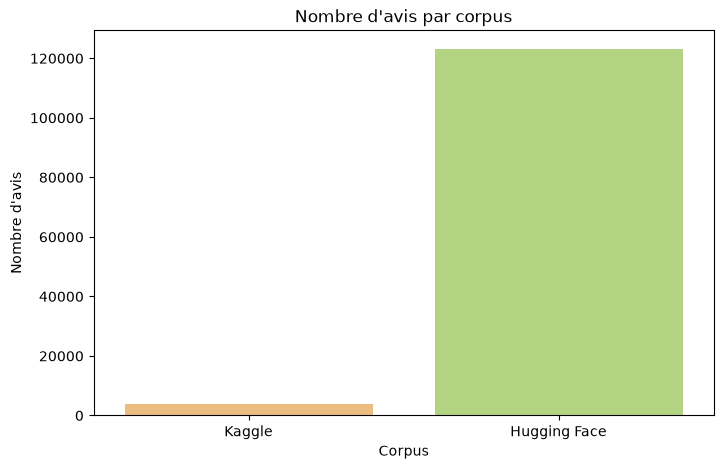

In [8]:
volume = pd.DataFrame({
    "Corpus": ["Kaggle", "Hugging Face"],
    "Nombre_avis": [len(df_kaggle), len(df_hf)]})

plt.figure(figsize=(8, 5))
sns.barplot(x="Corpus", y="Nombre_avis", hue="Corpus", palette="RdYlGn", data=volume)
plt.title("Nombre d'avis par corpus")
plt.xlabel("Corpus")
plt.ylabel("Nombre d'avis")
plt.show()

In [34]:
# Copie pour analyser les titres
df_titres = df_hf[["title"]].copy()

# Normalisation simple des titres
df_titres["title_normalise"] = (df_titres["title"].astype(str).str.lower().str.strip().str.replace(r"\s+", " ", regex=True))

print("Doublons exacts de title :",df_hf["title"].duplicated().sum())

print("Doublons après normalisation simple :",df_titres["title_normalise"].duplicated().sum())

titres_frequents = (df_titres["title_normalise"].value_counts().head(15))

display(titres_frequents)

Doublons exacts de title : 12038
Doublons après normalisation simple : 14912


title_normalise
great service                 464
excellent service             455
disappointed                  278
good service                  208
great customer service        203
disappointing                 182
excellent customer service    180
poor customer service         161
great experience              139
poor service                  136
excellent                     125
avoid                          94
good                           87
good customer service          87
great company                  82
Name: count, dtype: int64

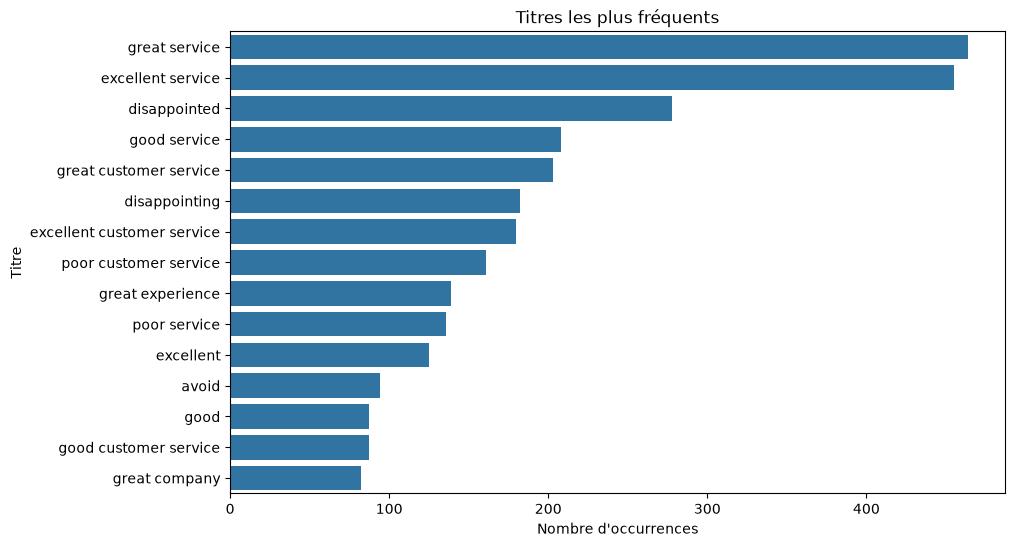

In [44]:
plt.figure(figsize=(10, 6))

sns.barplot(x=titres_frequents.values,y=titres_frequents.index,hue=titres_frequents.index,palette=["#1f77b4"] * len(titres_frequents),legend=False)

plt.title("Titres les plus fréquents")
plt.xlabel("Nombre d'occurrences")
plt.ylabel("Titre")

plt.show()

### Interprétation

Les titres les plus répétés sont généralement des formulations courtes et génériques comme `great service`, `excellent service`, `disappointed` ou `good service`. Le titre contient donc souvent un signal de sentiment intéressant, mais il ne semble pas suffisamment spécifique pour être exploité seul.

## 3. Entreprises

In [11]:
avis_par_entreprise = df_hf["company"].value_counts()

print("Nombre d'entreprises :", df_hf["company"].nunique())
display('Résumé statistique du nombre d’avis par entreprise : ', 
        avis_par_entreprise.describe())

Nombre d'entreprises : 1680


'Résumé statistique du nombre d’avis par entreprise : '

count    1680.000000
mean       73.322024
std        30.669449
min         1.000000
25%        46.000000
50%        89.000000
75%       100.000000
max       100.000000
Name: count, dtype: float64

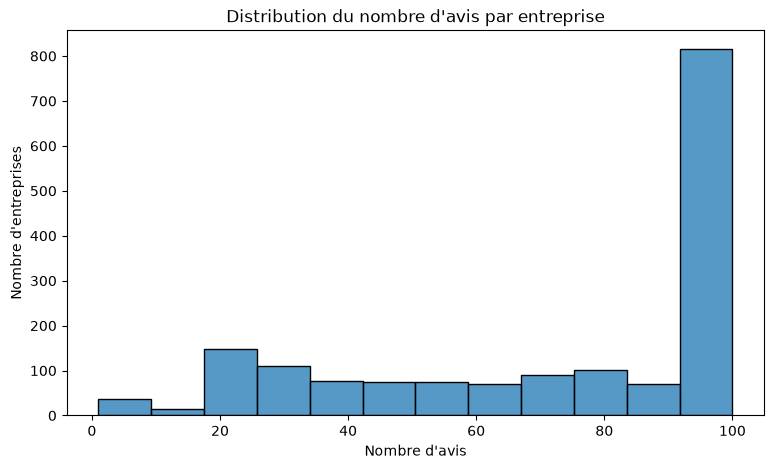

In [12]:
plt.figure(figsize=(9, 5))
sns.histplot(avis_par_entreprise)
plt.title("Distribution du nombre d'avis par entreprise")
plt.xlabel("Nombre d'avis")
plt.ylabel("Nombre d'entreprises")
plt.show()

### Interprétation

Le dataset **Hugging Face** contient **1 680 entreprises**. Le nombre d’avis varie fortement d’une entreprise à l’autre, avec une médiane élevée et plusieurs entreprises atteignant **100 avis**. Cette répartition suggère déjà l’existence d’un mécanisme de sélection des avis, qui sera analysé plus précisément dans la suite du notebook.

## 4. Catégories

In [13]:
avis_par_categorie = df_hf["category"].value_counts()
proportion_categorie = df_hf["category"].value_counts(normalize=True) * 100

display(proportion_categorie)

category
Education & Training            5.167193
Business Services               5.025126
Home & Garden                   4.985347
Sports                          4.979664
Food, Beverages & Tobacco       4.785641
Shopping & Fashion              4.703647
Vehicles & Transportation       4.680105
Money & Insurance               4.650880
Health & Medical                4.583499
Utilities                       4.575381
Electronics & Technology        4.542908
Animals & Pets                  4.421136
Travel & Vacation               4.404088
Home Services                   4.373239
Media & Publishing              4.344014
Construction & Manufacturing    4.334272
Hobbies & Crafts                4.321283
Events & Entertainment          4.300988
Restaurants & Bars              4.224678
Public & Local Services         4.222242
Beauty & Well-being             4.220618
Legal Services & Government     4.154050
Name: proportion, dtype: float64

In [14]:

entreprises_par_categorie = (df_hf.groupby("category")["company"].nunique()
    .sort_values(ascending=False))

print("Nombre d'entreprises par catégorie :")
display(entreprises_par_categorie)

Nombre d'entreprises par catégorie :


category
Restaurants & Bars              100
Food, Beverages & Tobacco        93
Business Services                89
Sports                           87
Education & Training             86
Hobbies & Crafts                 84
Home Services                    83
Animals & Pets                   83
Public & Local Services          80
Legal Services & Government      78
Events & Entertainment           76
Home & Garden                    76
Health & Medical                 76
Beauty & Well-being              72
Money & Insurance                70
Electronics & Technology         69
Utilities                        68
Construction & Manufacturing     67
Shopping & Fashion               67
Vehicles & Transportation        60
Media & Publishing               59
Travel & Vacation                57
Name: company, dtype: int64

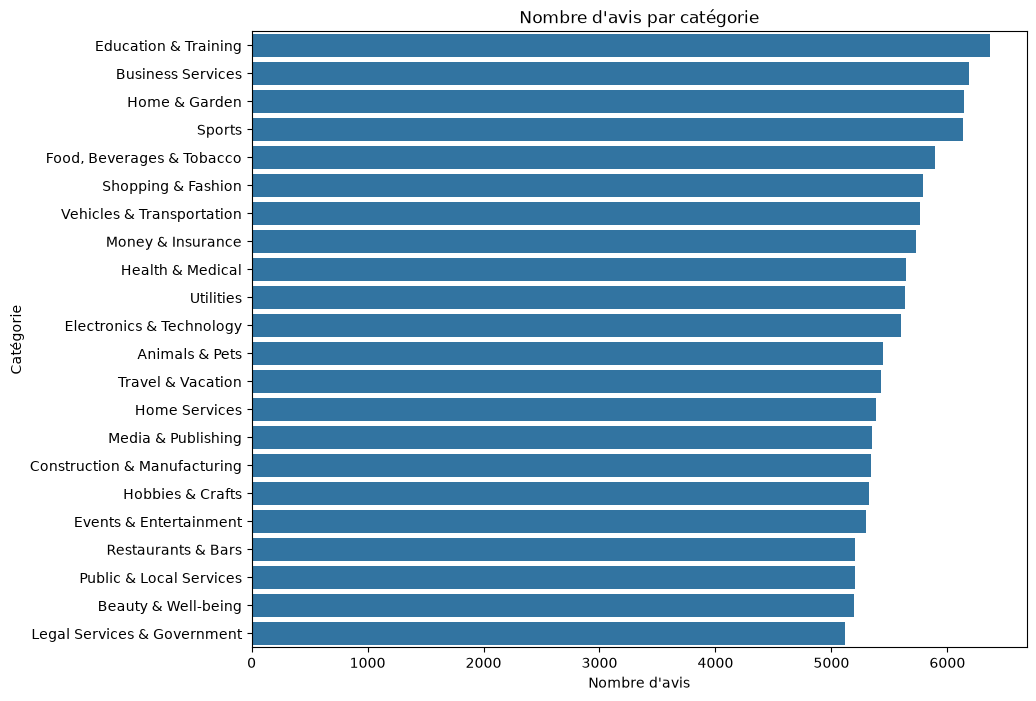

In [15]:
plt.figure(figsize=(10, 8))

sns.barplot(x=avis_par_categorie.values, y=avis_par_categorie.index)

plt.title("Nombre d'avis par catégorie")
plt.xlabel("Nombre d'avis")
plt.ylabel("Catégorie")
plt.show()

### Interprétation

Le dataset **Hugging Face** contient **22 catégories** et couvre donc des secteurs d'activité variés. La répartition relativement équilibrée des avis entre les catégories apporte de la diversité au corpus, mais peut également refléter une sélection réalisée lors de sa constitution.

La variable `category` est particulièrement utile pour le projet : les aspects importants peuvent varier selon le secteur. Par exemple, des sujets liés à la **livraison** peuvent être davantage pertinents pour certaines activités commerciales que pour d'autres. Les catégories permettront donc de contextualiser les aspects identifiés dans les avis.
La variable `category` pourra également être utilisée comme information de contexte métier. Les aspects importants peuvent varier selon les secteurs : par exemple, la livraison et les retours peuvent être particulièrement importants dans `Shopping & Fashion` ou `Electronics & Technology`, alors que d'autres secteurs peuvent davantage faire ressortir le service client, le paiement ou le remboursement.

## 5. Notes

In [16]:
display(df_hf["stars"].value_counts().sort_index())
display(df_hf["stars"].value_counts(normalize=True).sort_index() * 100)

stars
1    24065
2    19687
3    21264
4    26013
5    32152
Name: count, dtype: int64

stars
1    19.536292
2    15.982173
3    17.262402
4    21.117705
5    26.101428
Name: proportion, dtype: float64

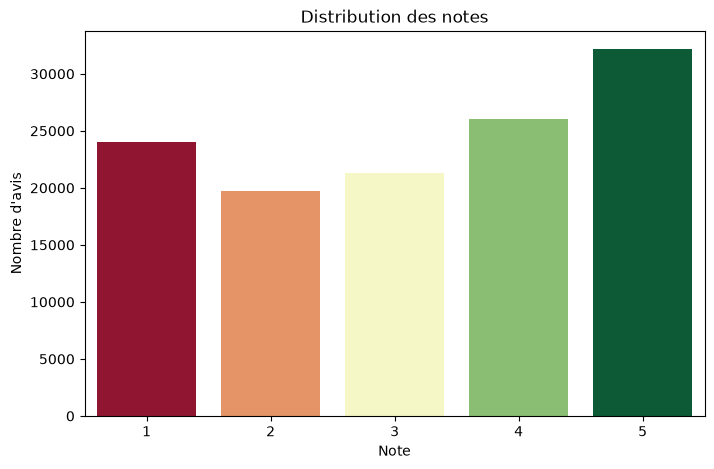

In [17]:
plt.figure(figsize=(8, 5))
sns.countplot(x="stars", data=df_hf, hue="stars", palette="RdYlGn",legend=False)
plt.title("Distribution des notes")
plt.xlabel("Note")
plt.ylabel("Nombre d'avis")
plt.show()

### Interprétation

La distribution des notes est relativement équilibrée entre **1 et 5 étoiles**. Cette forme est atypique par rapport à un repère public fourni par Trustpilot : dans son **Transparency Report 2022**, la plateforme indiquait que **72,51 %** des avis soumis étaient des avis à **5 étoiles**, contre **13,56 %** à **1 étoile**.

L'équilibre observé dans Hugging Face ne doit donc pas être considéré comme représentatif de la distribution réelle des avis Trustpilot. Il suggère plutôt un mécanisme de sélection du corpus, qui sera vérifié dans la section 7.

## 6. Note moyenne par entreprise

In [18]:
moyenne_stars_entreprise = df_hf.groupby("company")["stars"].mean()
display(moyenne_stars_entreprise.describe())

count    1680.000000
mean        3.409527
std         0.668724
min         1.000000
25%         3.000000
50%         3.019905
75%         3.743040
max         5.000000
Name: stars, dtype: float64

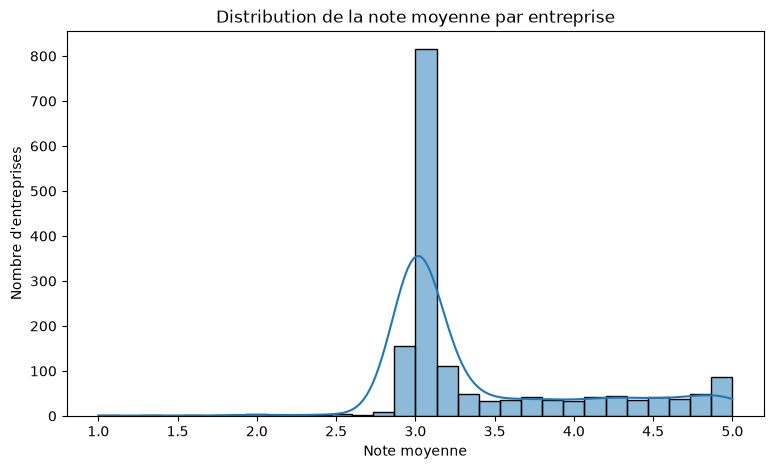

In [19]:
plt.figure(figsize=(9, 5))

sns.histplot(moyenne_stars_entreprise,bins=30, kde=True)

plt.title("Distribution de la note moyenne par entreprise")
plt.xlabel("Note moyenne")
plt.ylabel("Nombre d'entreprises")
plt.show()

In [20]:
print("Entreprises avec une moyenne exactement égale à 3 :",
      (moyenne_stars_entreprise == 3).sum())

print("Entreprises avec une moyenne entre 2.95 et 3.05 :",
      ((moyenne_stars_entreprise >= 2.95)&(moyenne_stars_entreprise <= 3.05)).sum())

Entreprises avec une moyenne exactement égale à 3 : 611
Entreprises avec une moyenne entre 2.95 et 3.05 : 833


### Interprétation

La note moyenne par entreprise est fortement concentrée autour de **3** : (1 + 2 + 3 + 4 + 5) / 5 = 3. Cette concentration est particulièrement marquée, avec de nombreuses entreprises présentant une moyenne proche de 3. Cette observation suggère l’existence d’un mécanisme particulier dans la construction du dataset, qui sera vérifié dans la section suivante.

## 7. Vérification du mécanisme d'échantillonnage

In [21]:
repartition_stars_entreprise = (df_hf.groupby(["company", "stars"]).size()
                                                                   .unstack(fill_value=0))

repartition_stars_entreprise.head()

stars,1,2,3,4,5
company,,,,,
101petexpress.com,0,0,0,1,20
123sheets.co.uk,10,10,19,19,20
1stchoice.co.uk,20,20,20,20,20
21d.co.uk,8,0,0,2,20
360.optimalegal.co.uk,20,20,20,20,20


In [22]:
print("Maximum par note et par entreprise")
display(repartition_stars_entreprise.max())

print("Nombre d'entreprises dépassant 20 avis pour une même note")
display((repartition_stars_entreprise > 20).sum())

Maximum par note et par entreprise


stars
1    20
2    20
3    20
4    20
5    20
dtype: int64

Nombre d'entreprises dépassant 20 avis pour une même note


stars
1    0
2    0
3    0
4    0
5    0
dtype: int64

In [23]:
avis_par_entreprise = df_hf["company"].value_counts()

entreprises_100 = avis_par_entreprise[avis_par_entreprise == 100].index
repartition_100 = repartition_stars_entreprise.loc[entreprises_100]

print("Nombre d'entreprises avec exactement 100 avis :", len(entreprises_100))

print("Parmi elles, nombre avec exactement 20 avis pour chacune des 5 notes :",
      (repartition_100 == 20).all(axis=1).sum())

Nombre d'entreprises avec exactement 100 avis : 558
Parmi elles, nombre avec exactement 20 avis pour chacune des 5 notes : 558


### Interprétation

La vérification confirme l’existence d’un **mécanisme d’échantillonnage** : le nombre d’avis est plafonné à **20 avis par note et par entreprise**. Ainsi, certaines entreprises disposent de 20 avis pour chacune des notes de 1 à 5 étoiles, ce qui entraîne mécaniquement une note moyenne de **3/5**.

### Conclusion sur le biais

Le corpus **Hugging Face** impose un maximum de **20 avis par note et par entreprise**. Les entreprises ayant **100 avis** disposent donc de **20 avis pour chacune des cinq notes**, ce qui produit mécaniquement une moyenne de **3/5**.



## 8. Longueur des textes

In [24]:
df_hf["longueur_review"] = df_hf["review"].astype(str).apply(len)
display(df_hf["longueur_review"].describe())

count    123181.000000
mean        358.787305
std         314.553061
min          10.000000
25%         177.000000
50%         290.000000
75%         440.000000
max        9956.000000
Name: longueur_review, dtype: float64

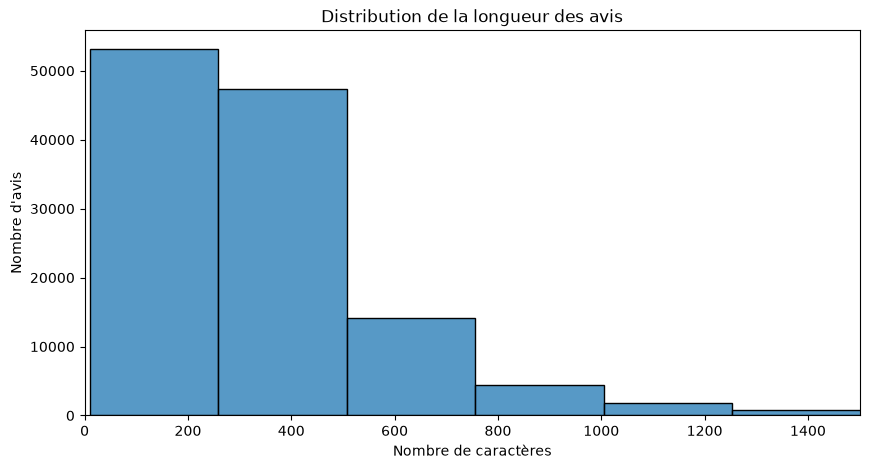

In [25]:
plt.figure(figsize=(10, 5))

sns.histplot(df_hf["longueur_review"],bins=40)

plt.xlim(0, 1500)
plt.title("Distribution de la longueur des avis")
plt.xlabel("Nombre de caractères")
plt.ylabel("Nombre d'avis")
plt.show()

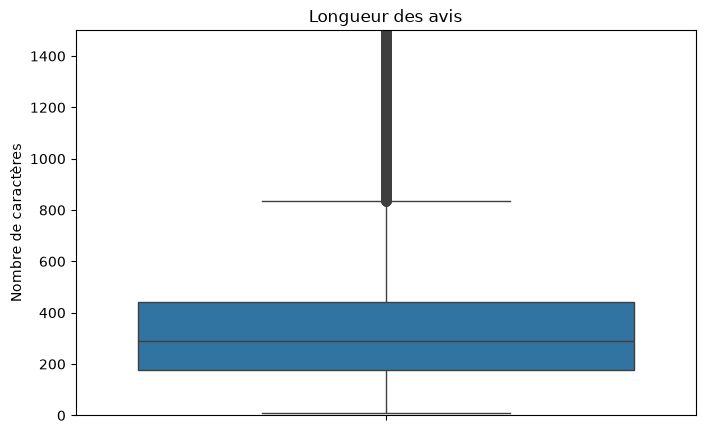

In [26]:
plt.figure(figsize=(8, 5))

sns.boxplot(y="longueur_review",data=df_hf)

plt.ylim(0, 1500)
plt.title("Longueur des avis")
plt.ylabel("Nombre de caractères")
plt.show()

### Interprétation

Les avis du dataset **Hugging Face** sont globalement assez développés, avec une longueur médiane d’environ **290 caractères**. La majorité des avis reste de taille raisonnable, mais certains textes sont beaucoup plus longs. Cette richesse textuelle est intéressante pour la suite du projet, car elle fournit davantage d’informations pour identifier les aspects abordés et analyser les sentiments exprimés.

## 9. Analyse de la récurrence des mots

Cette analyse permet d'identifier les termes les plus fréquents dans les avis. Elle constitue une première exploration du vocabulaire du corpus avant la modélisation NLP.

Le texte brut de la colonne `review` est **conservé intact**. Une copie simplifiée est créée uniquement pour l'analyse lexicale : passage en minuscules, suppression de la ponctuation, découpage en mots et retrait de quelques mots très fréquents peu informatifs.

Cette précaution est importante : le prétraitement utilisé pour cette analyse peut servir de base à certains traitements NLP classiques, mais il ne doit pas être appliqué automatiquement à tous les futurs modèles. **RoBERTa utilise son propre tokenizer** et le **NER peut avoir besoin de conserver la casse et la ponctuation**.

In [27]:
# creation de copie de review
df_mots = df_hf[["review"]].copy()

# text en chaine, en miniscule, remp. ponctuation/chiffres/caractères spéciaux par des espaces
df_mots["review_nettoye"] = (df_mots["review"].astype(str).str.lower()
    .str.replace(r"[^a-z\s']", " ", regex=True))

# avis en liste de mots et met un mot par ligne
mots = df_mots["review_nettoye"].str.split().explode()

# on retir les mots très fréquents
mots_a_retirer = ["the", "a", "an", "and", "or", "but", "of", "to", "in", "on", "for",
                  "is", "it", "this", "that", "was", "were", "are", "be", "been", "with",
                  "my", "i", "you", "they", "we", "he", "she", "as", "at", "from", "by"]

mots_utiles = mots[(~mots.isin(mots_a_retirer)) & (mots.str.len() > 2)]

frequence_mots = mots_utiles.value_counts().head(20)

frequence_tous_mots = mots_utiles.value_counts()

rang_mots = pd.Series(range(1, len(frequence_tous_mots) + 1),
                      index=frequence_tous_mots.index)

tableau_mots = pd.DataFrame({"Frequence": frequence_mots,
                             "Rang_global": rang_mots[frequence_mots.index]})

display(tableau_mots)
print("Nombre total de mots utiles :", len(mots_utiles))
nb_mots_uniques = mots_utiles.nunique()
print("Nombre de mots utiles différents :", nb_mots_uniques)

,Frequence,Rang_global
review_nettoye,,
have,67429,1
not,66059,2
had,48609,3
very,44108,4
would,32653,5
service,32548,6
all,28700,7
time,28470,8
them,28206,9


Nombre total de mots utiles : 4896040
Nombre de mots utiles différents : 73755


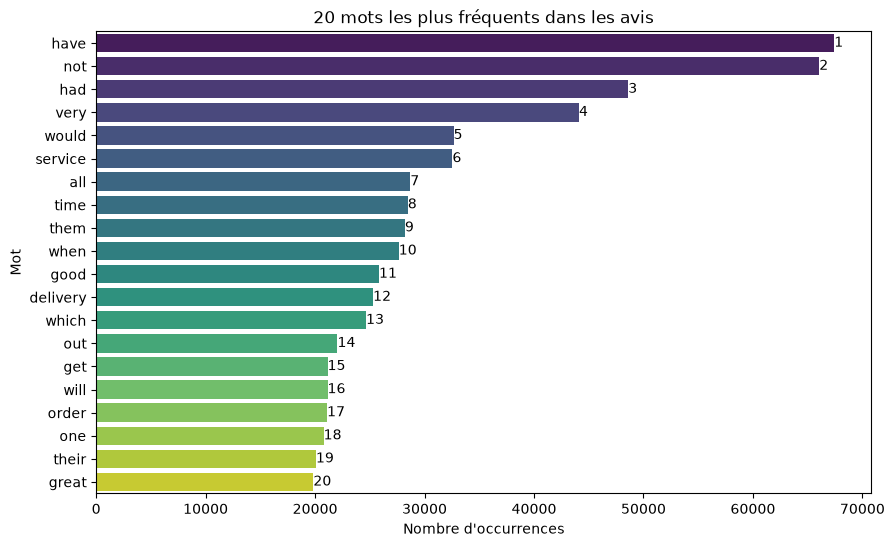

In [28]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(x=frequence_mots.values, y=frequence_mots.index,
                 hue=frequence_mots.index, palette="viridis", legend=False)

for i, mot in enumerate(frequence_mots.index):
    ax.text(frequence_mots.values[i], i, rang_mots[mot], va="center")
    
plt.title("20 mots les plus fréquents dans les avis")
plt.xlabel("Nombre d'occurrences")
plt.ylabel("Mot")

plt.show()

### Interprétation

Les mots les plus fréquents donnent un premier aperçu des sujets et du vocabulaire dominants dans le corpus. Cette analyse reste descriptive : un mot très fréquent n'est pas forcément un aspect métier important, et sa fréquence ne donne pas directement son sentiment.

Elle servira surtout de **contrôle exploratoire du corpus** avant les modèles plus avancés. Les résultats pourront ensuite être comparés aux aspects identifiés par RoBERTa ou aux thèmes découverts par BERTopic.

In [29]:
mots_aspects = ["service", "support", "customer", "staff",
                "delivery", "shipping", "order", "arrived",
                "product", "quality", "item", "broken","damaged",
                "price", "cost","purchase",
                "refund", "return", "replacement",
                "website", "app", "payment"]

frequence_aspects = mots_utiles[mots_utiles.isin(mots_aspects)].value_counts()

tableau_aspects = pd.DataFrame({"Frequence": frequence_aspects,
                                "Rang_global": rang_mots[frequence_aspects.index],
                                "Nb_mots_uniques": nb_mots_uniques})

display(tableau_aspects)

,Frequence,Rang_global,Nb_mots_uniques
review_nettoye,,,
service,32548,6,73755
delivery,25300,12,73755
order,21096,17,73755
customer,17876,26,73755
arrived,11071,58,73755
quality,8760,79,73755
price,8675,81,73755
product,8666,82,73755
refund,8514,83,73755


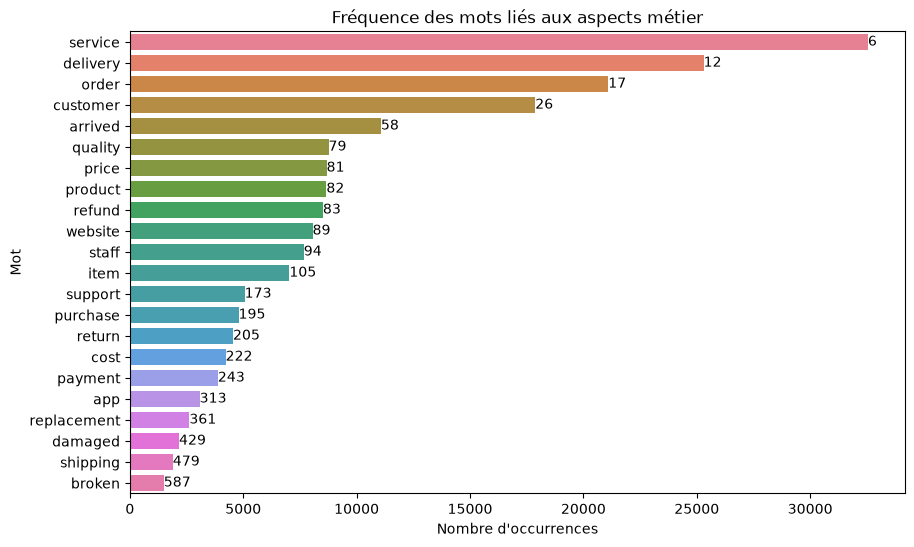

In [30]:
plt.figure(figsize=(10, 6))

ax1= sns.barplot(x=frequence_aspects.values, y=frequence_aspects.index,
                 hue=frequence_aspects.index, palette="husl", legend=False)

for i, mot in enumerate(frequence_aspects.index):
    ax1.text(frequence_aspects.values[i], i, rang_mots[mot], va="center")
    
plt.title("Fréquence des mots liés aux aspects métier")
plt.xlabel("Nombre d'occurrences")
plt.ylabel("Mot")

plt.show()

In [31]:
mots_sentiment = ["good", "great", "excellent",
                  "helpful", "easy", "fast",
                  "bad", "poor", "terrible", "slow", "late",
                  "problem", "issue", "disappointed"]

frequence_sentiment = mots_utiles[mots_utiles.isin(mots_sentiment)].value_counts()

tableau_sentiment = pd.DataFrame({"Frequence": frequence_sentiment,
                                  "Rang_global": rang_mots[frequence_sentiment.index]})

display(tableau_sentiment)

,Frequence,Rang_global
review_nettoye,,
good,25839,11
great,19842,20
helpful,10758,63
easy,9939,69
excellent,7655,96
issue,6707,113
problem,6150,129
poor,5742,147
disappointed,5238,167


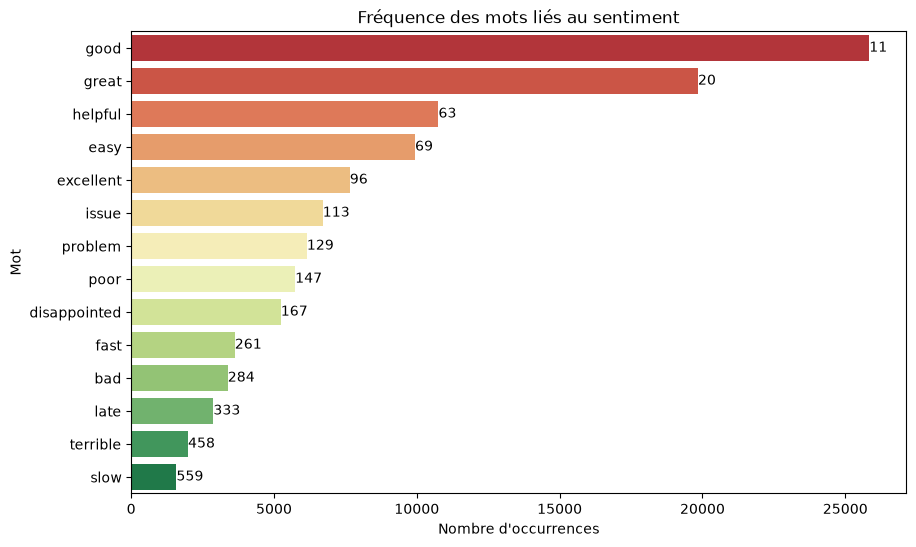

In [32]:
plt.figure(figsize=(10, 6))

ax2 = sns.barplot(x=frequence_sentiment.values, y=frequence_sentiment.index,
                  hue=frequence_sentiment.index, palette="RdYlGn", legend=False)

for i, mot in enumerate(frequence_sentiment.index):
    ax2.text(frequence_sentiment.values[i],
             i, rang_mots[mot], va="center")

plt.title("Fréquence des mots liés au sentiment")
plt.xlabel("Nombre d'occurrences")
plt.ylabel("Mot")

plt.show()

In [36]:
expressions_negatives = ["not good","not great","not helpful","not easy","not fast",
                         "wasn't good","wasn't great","isn't good","isn't great"]

frequence_negations = []

for expression in expressions_negatives:
    
    nb = df_mots["review_nettoye"].str.count(expression).sum()
    
    frequence_negations.append(nb)

tableau_negations = pd.DataFrame({"Expression": expressions_negatives,"Frequence": frequence_negations})

tableau_negations = tableau_negations.sort_values("Frequence",ascending=False)

display(tableau_negations)

,Expression,Frequence
0,not good,775
1,not great,474
3,not easy,197
2,not helpful,189
6,wasn't great,60
5,wasn't good,33
8,isn't great,29
4,not fast,22
7,isn't good,22


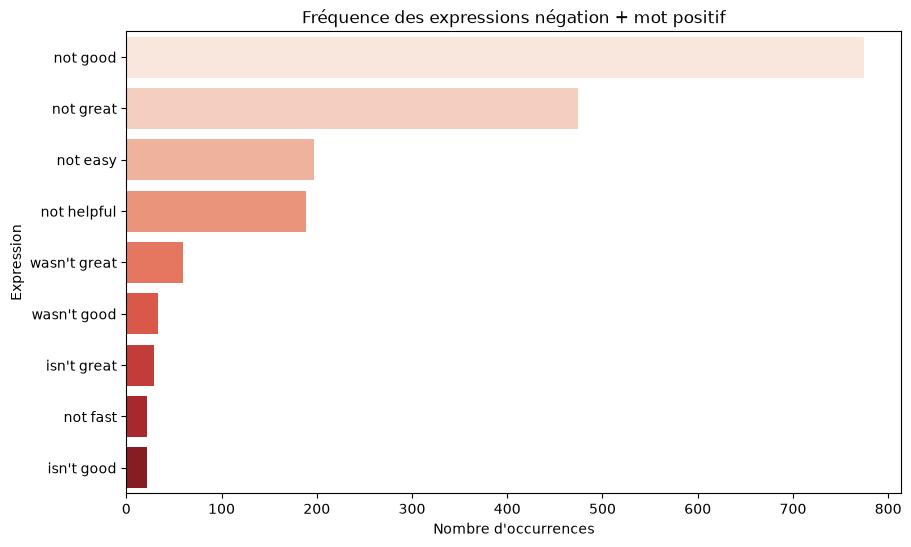

In [37]:
plt.figure(figsize=(10, 6))

sns.barplot(x="Frequence",y="Expression",hue="Expression",data=tableau_negations,palette="Reds",legend=False)

plt.title("Fréquence des expressions négation + mot positif")
plt.xlabel("Nombre d'occurrences")
plt.ylabel("Expression")

plt.show()

### Interprétation

Cette analyse montre une limite importante du comptage de mots isolés. Un mot considéré comme positif peut apparaître dans une formulation négative : par exemple, `good` apparaît également dans `not good`. La fréquence d'un mot ne permet donc pas, à elle seule, de déterminer le sentiment exprimé.

Cette observation justifie l'utilisation future d'un modèle contextuel comme **DistilBERT**, capable de prendre en compte les mots qui entourent le terme analysé.

In [33]:
expressions = ["customer service",
               "fast delivery",
               "late delivery",
               "slow delivery",
               "poor service",
               "good quality",
               "refund process"]

for expression in expressions:
    nb = df_mots["review_nettoye"].str.count(expression).sum()
    print(expression, ":", nb)

customer service : 12447
fast delivery : 999
late delivery : 78
slow delivery : 84
poor service : 621
good quality : 1361
refund process : 50


## 10. Création du corpus de travail pour le NLP

In [40]:
df_nlp = df_hf[["company", "category", "title", "review", "stars"]].copy()

df_nlp["texte_complet"] = (df_nlp["title"].astype(str) + " " + df_nlp["review"].astype(str))

df_nlp["longueur_review"] = (df_nlp["review"].astype(str).apply(len))

df_nlp.head()

,company,category,title,review,stars,texte_complet,longueur_review
0,ruffandtumbledogcoats.com,Animals & Pets,Great quality dog drying robe although…,Great quality dog drying robe although had to ...,5,Great quality dog drying robe although… Great ...,89
1,ruffandtumbledogcoats.com,Animals & Pets,Really prompt service,"Really prompt service, The sofa covers have no...",5,"Really prompt service Really prompt service, T...",202
2,ruffandtumbledogcoats.com,Animals & Pets,Life saver,I’ve purchased first of those coats in May2020...,5,Life saver I’ve purchased first of those coats...,469
3,ruffandtumbledogcoats.com,Animals & Pets,Brilliant coats,Brilliant coats. Really like the limited editi...,5,Brilliant coats Brilliant coats. Really like t...,260
4,ruffandtumbledogcoats.com,Animals & Pets,Great company and products,Great company and products. This is my 3rd dry...,5,Great company and products Great company and p...,157


### Interprétation

Ce DataFrame de travail conserve les variables utiles pour la suite du projet tout en laissant le dataset d'origine inchangé. La colonne `review` reste la variable textuelle principale, tandis que `company`, `category` et `stars` permettront de contextualiser les analyses.

Une nouvelle variable `texte_complet`, construite à partir de `title + review`, est également créée afin de pouvoir tester plus tard si l'ajout du titre améliore les performances des modèles par rapport à l'utilisation du corps de l'avis seul.

Une version nettoyée ou lemmatisée du corpus pourra éventuellement être préparée pour certains usages exploratoires futurs, notamment le topic modeling ou le clustering. Elle n'est pas créée à ce stade, car le prétraitement devra être adapté au modèle retenu et le texte brut doit être conservé pour les modèles contextuels comme DistilBERT.

## 11. Limites méthodologiques du corpus

Plusieurs limites doivent être prises en compte avant la modélisation :

- le corpus a été collecté sur une période courte, du **19 décembre 2024 au 7 janvier 2025**, correspondant aux fêtes de fin d'année. Certains sujets comme les **livraisons, retards, retours, commandes ou interactions avec le service client** peuvent donc être davantage représentés sur cette période ;
- les **dates individuelles des avis ne sont pas disponibles**, ce qui empêche de mesurer directement cet éventuel effet saisonnier ;
- l'absence totale de valeurs manquantes peut résulter d'un nettoyage réalisé en amont, par exemple par suppression des lignes incomplètes ou remplissage de certaines valeurs. Ces éventuelles opérations ne sont pas documentées ;
- le plafonnement observé à **20 avis par note et par entreprise** rend la distribution des étoiles artificielle et ne reflète donc pas fidèlement la **note réelle de l'entreprise sur Trustpilot** ;
- les avis proviennent de **Trustpilot UK** et sont majoritairement rédigés en anglais britannique. Cette spécificité doit être prise en compte si le modèle est ensuite appliqué à d'autres pays, langues ou contextes culturels ;
- enfin, les analyses lexicales réalisées à partir de mots isolés restent limitées, car elles ne prennent pas toujours en compte le contexte, les négations ou les expressions composées. Cette limite justifie l'utilisation future de modèles contextuels comme **DistilBERT**.


## Conclusion

L'analyse exploratoire confirme que **Hugging Face** constitue une base intéressante pour la suite du projet de traitement automatique du langage naturel (**NLP**). Le corpus contient **123 181 avis**, **1 680 entreprises** et **22 catégories**, avec des textes relativement riches et une diversité sectorielle utile pour contextualiser les aspects étudiés.

L'analyse met toutefois en évidence un biais important dans sa constitution : le nombre d'avis observé est plafonné à **20 avis par note et par entreprise**. Les entreprises disposant de **100 avis** ont ainsi 20 avis pour chacune des cinq notes, ce qui entraîne mécaniquement une moyenne de **3/5**. La distribution de `stars` et les notes moyennes par entreprise ne reflètent donc pas fidèlement la **note réelle de l'entreprise sur Trustpilot**.

L'absence totale de valeurs manquantes facilite l'exploitation du corpus mais ne doit pas être interprétée comme une preuve suffisante de qualité. Des suppressions de lignes incomplètes ou des remplissages peuvent avoir été réalisés lors du prétraitement, sans que ces étapes soient documentées. À l'inverse, un volume important de NA sur des variables utiles aurait nécessité davantage de traitement et aurait pu entraîner une perte d'information.

L'analyse de la **récurrence des mots**, puis des termes liés aux **aspects métier** et au **sentiment**, apporte un premier aperçu du vocabulaire dominant du corpus. Les analyses de certaines expressions, notamment les formulations de type `not good` ou `not great`, montrent cependant les limites d'une approche basée uniquement sur le comptage de mots isolés : le sens d'un terme dépend fortement de son contexte. Cette observation renforce l'intérêt d'utiliser par la suite un modèle contextuel comme **DistilBERT** pour l'analyse des aspects et du sentiment.

Le texte brut reste conservé, car le prétraitement devra être adapté au modèle utilisé. Une variable `texte_complet`, construite à partir de `title + review`, a également été préparée afin de pouvoir tester ultérieurement si l'ajout du titre apporte une information utile pour la modélisation.

La variable `category` sera conservée afin de replacer les aspects dans leur contexte sectoriel. Enfin, la courte période de collecte (**19 décembre 2024 – 7 janvier 2025**) et l'absence de dates individuelles constituent une limite importante : un éventuel effet lié aux fêtes de fin d'année ne pourra pas être mesuré directement.

La suite du projet pourra donc se concentrer sur la préparation et la modélisation NLP pour **identifier les aspects connus et leur sentiment, découvrir des thèmes émergents et produire des recommandations métier**, tout en tenant compte des biais et limites identifiés lors de cette phase exploratoire.